# RNN, LSTM & GRU on MNIST
## Sequence Modeling for Image Classification

This notebook uses the **same Kaggle Digit Recognizer MNIST CSV dataset** as the CNN project.

Models:
- Simple RNN
- LSTM
- GRU

The 28×28 image is represented as **28 time steps × 28 features**.

Expected local files:
```text
8.mnist-digit-recognition-with-cnn/
├── train.csv
├── test.csv
└── sample_submission.csv
```

In [1]:
from pathlib import Path
import random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

BASE_PATH = Path(r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn")
TRAIN_PATH = BASE_PATH / "train.csv"
TEST_PATH = BASE_PATH / "test.csv"
SAMPLE_SUBMISSION_PATH = BASE_PATH / "sample_submission.csv"

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("Sample exists:", SAMPLE_SUBMISSION_PATH.exists())

TensorFlow: 2.21.0
GPU: []
Train exists: True
Test exists: True
Sample exists: True


## 1. Load and Inspect the Same Dataset

`train.csv` contains `label` + 784 pixel columns.

`test.csv` contains 784 pixel columns and **does not contain labels**, so local test accuracy cannot be calculated.

In [2]:
train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

X = train_data.drop(columns=["label"]).values.astype("float32") / 255.0
y = train_data["label"].values
X_test_flat = test_data.values.astype("float32") / 255.0

print("Train:", train_data.shape)
print("Test :", test_data.shape)
print("X:", X.shape, "y:", y.shape, "X_test:", X_test_flat.shape)

Train: (42000, 785)
Test : (28000, 784)
X: (42000, 784) y: (42000,) X_test: (28000, 784)


## 2. Train/Validation Split and Sequence Reshape

For recurrent models:

```text
784 pixels → 28 × 28
             ↑    ↑
          timesteps features
```

So the model input is `(28, 28)`.

In [3]:
X_train_flat, X_val_flat, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=y
)

X_train = X_train_flat.reshape(-1, 28, 28)
X_val = X_val_flat.reshape(-1, 28, 28)
X_test = X_test_flat.reshape(-1, 28, 28)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (37800, 28, 28)
X_val  : (4200, 28, 28)
X_test : (28000, 28, 28)


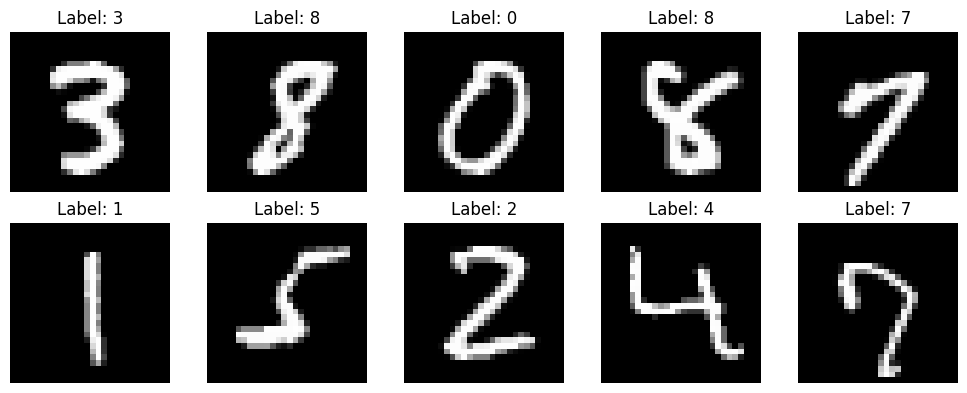

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Build the Three Models

### Simple RNN
Processes the 28 image rows sequentially.

### LSTM
Uses gated memory with forget, input, and output mechanisms.

### GRU
Uses update/reset gating with a simpler recurrent structure than LSTM.

All three use the same input shape, optimizer, loss, and basic dense classification head for a fair learning comparison.

In [5]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_rnn():
    return compile_model(tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.SimpleRNN(64),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(10, activation="softmax")
    ]))

def build_lstm():
    return compile_model(tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(10, activation="softmax")
    ]))

def build_gru():
    return compile_model(tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(10, activation="softmax")
    ]))

rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

print("RNN")
rnn_model.summary()
print("\nLSTM")
lstm_model.summary()
print("\nGRU")
gru_model.summary()

RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,762 (42.04 KB)

 Trainable params: 10,762 (42.04 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,858 (89.29 KB)

 Trainable params: 22,858 (89.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 15
BATCH_SIZE = 128

def callbacks_for(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max", patience=3,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1,
            min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f"{name}_best.keras", monitor="val_accuracy",
            mode="max", save_best_only=True, verbose=1
        )
    ]

## 4. Train Simple RNN

In [7]:
start = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for("rnn"),
    verbose=2
)
rnn_time = time.time() - start
print(f"RNN training time: {rnn_time/60:.2f} minutes")

Epoch 1/15

Epoch 1: val_accuracy improved from None to 0.86167, saving model to rnn_best.keras
296/296 - 3s - 11ms/step - accuracy: 0.6801 - loss: 0.9468 - val_accuracy: 0.8617 - val_loss: 0.4254 - learning_rate: 0.0010
Epoch 2/15

Epoch 2: val_accuracy improved from 0.86167 to 0.90119, saving model to rnn_best.keras
296/296 - 2s - 5ms/step - accuracy: 0.8756 - loss: 0.4075 - val_accuracy: 0.9012 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 3/15

Epoch 3: val_accuracy improved from 0.90119 to 0.92619, saving model to rnn_best.keras
296/296 - 1s - 5ms/step - accuracy: 0.9098 - loss: 0.3068 - val_accuracy: 0.9262 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 4/15

Epoch 4: val_accuracy improved from 0.92619 to 0.94000, saving model to rnn_best.keras
296/296 - 1s - 5ms/step - accuracy: 0.9212 - loss: 0.2678 - val_accuracy: 0.9400 - val_loss: 0.1939 - learning_rate: 0.0010
Epoch 5/15

Epoch 5: val_accuracy improved from 0.94000 to 0.94357, saving model to rnn_best.keras
296/296 - 1

## 5. Train LSTM

In [8]:
start = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for("lstm"),
    verbose=2
)
lstm_time = time.time() - start
print(f"LSTM training time: {lstm_time/60:.2f} minutes")

Epoch 1/15

Epoch 1: val_accuracy improved from None to 0.89000, saving model to lstm_best.keras
296/296 - 5s - 17ms/step - accuracy: 0.6724 - loss: 0.9724 - val_accuracy: 0.8900 - val_loss: 0.3494 - learning_rate: 0.0010
Epoch 2/15

Epoch 2: val_accuracy improved from 0.89000 to 0.92357, saving model to lstm_best.keras
296/296 - 4s - 12ms/step - accuracy: 0.8997 - loss: 0.3313 - val_accuracy: 0.9236 - val_loss: 0.2368 - learning_rate: 0.0010
Epoch 3/15

Epoch 3: val_accuracy improved from 0.92357 to 0.95095, saving model to lstm_best.keras
296/296 - 3s - 12ms/step - accuracy: 0.9349 - loss: 0.2244 - val_accuracy: 0.9510 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 4/15

Epoch 4: val_accuracy improved from 0.95095 to 0.95500, saving model to lstm_best.keras
296/296 - 3s - 12ms/step - accuracy: 0.9496 - loss: 0.1719 - val_accuracy: 0.9550 - val_loss: 0.1501 - learning_rate: 0.0010
Epoch 5/15

Epoch 5: val_accuracy improved from 0.95500 to 0.95857, saving model to lstm_best.keras
296

## 6. Train GRU

In [10]:
start = time.time()
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for("gru"),
    verbose=2
)
gru_time = time.time() - start
print(f"GRU training time: {gru_time/60:.2f} minutes")

Epoch 1/15

Epoch 1: val_accuracy improved from None to 0.83167, saving model to gru_best.keras
296/296 - 6s - 19ms/step - accuracy: 0.6011 - loss: 1.1512 - val_accuracy: 0.8317 - val_loss: 0.5239 - learning_rate: 0.0010
Epoch 2/15

Epoch 2: val_accuracy improved from 0.83167 to 0.91571, saving model to gru_best.keras
296/296 - 4s - 12ms/step - accuracy: 0.8707 - loss: 0.4293 - val_accuracy: 0.9157 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 3/15

Epoch 3: val_accuracy improved from 0.91571 to 0.93405, saving model to gru_best.keras
296/296 - 3s - 11ms/step - accuracy: 0.9198 - loss: 0.2806 - val_accuracy: 0.9340 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 4/15

Epoch 4: val_accuracy improved from 0.93405 to 0.95071, saving model to gru_best.keras
296/296 - 3s - 12ms/step - accuracy: 0.9387 - loss: 0.2138 - val_accuracy: 0.9507 - val_loss: 0.1563 - learning_rate: 0.0010
Epoch 5/15

Epoch 5: val_accuracy improved from 0.95071 to 0.95786, saving model to gru_best.keras
296/296 

## 7. Compare Learning Curves

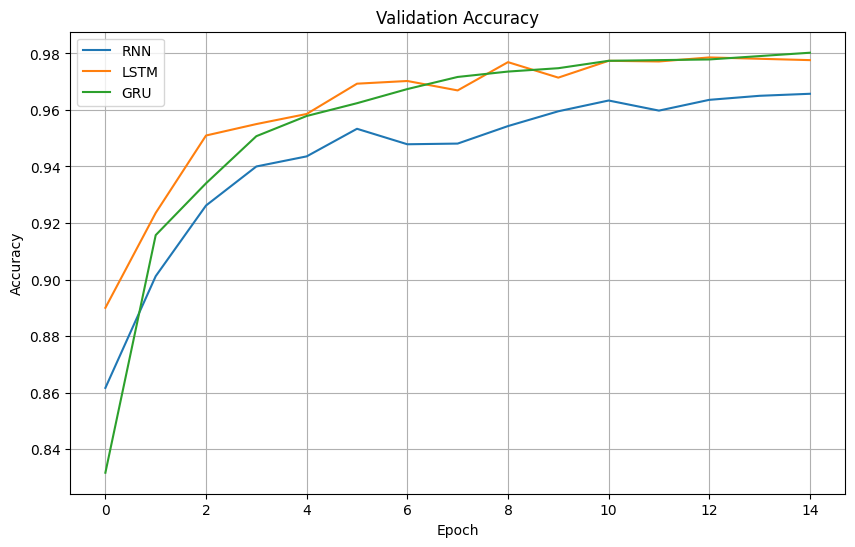

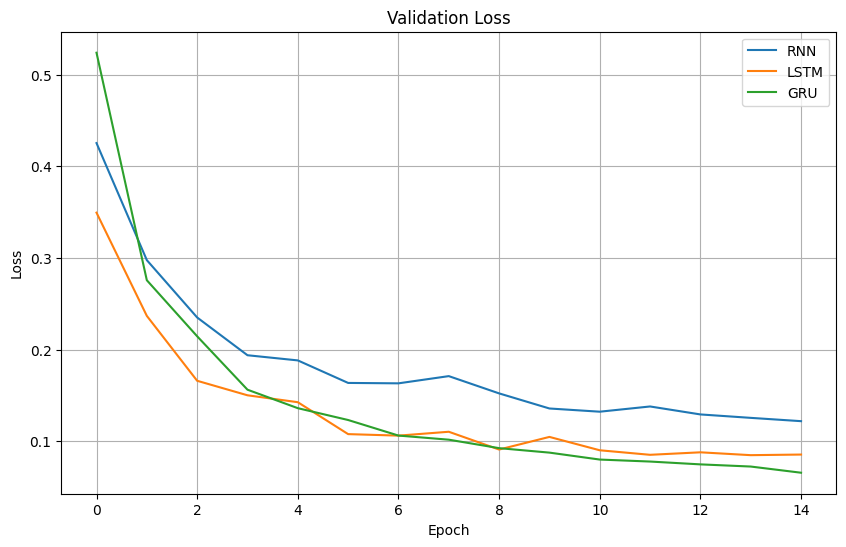

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(rnn_history.history["val_accuracy"], label="RNN")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM")
plt.plot(gru_history.history["val_accuracy"], label="GRU")
plt.title("Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(10, 6))
plt.plot(rnn_history.history["val_loss"], label="RNN")
plt.plot(lstm_history.history["val_loss"], label="LSTM")
plt.plot(gru_history.history["val_loss"], label="GRU")
plt.title("Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.show()

## 8. Evaluate RNN, LSTM and GRU

Metrics:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Parameter count
- Training time

In [12]:
def evaluate_model(model, name, train_time):
    prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(prob, axis=1)
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Macro Precision": precision_score(y_val, pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_val, pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_val, pred, average="macro", zero_division=0),
        "Parameters": model.count_params(),
        "Training Time (min)": train_time / 60
    }
    return result, pred, prob

rnn_result, rnn_val_pred, rnn_val_prob = evaluate_model(rnn_model, "RNN", rnn_time)
lstm_result, lstm_val_pred, lstm_val_prob = evaluate_model(lstm_model, "LSTM", lstm_time)
gru_result, gru_val_pred, gru_val_prob = evaluate_model(gru_model, "GRU", gru_time)

results_df = pd.DataFrame([rnn_result, lstm_result, gru_result])
display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (min)
0,RNN,0.965714,0.965458,0.965405,0.965321,10762,0.410839
1,LSTM,0.978571,0.978472,0.978502,0.978418,28618,0.933271
2,GRU,0.980238,0.980009,0.979979,0.979964,22858,0.936129


In [13]:
print("="*70)
print("RNN")
print("="*70)
print(classification_report(y_val, rnn_val_pred, digits=4))

print("="*70)
print("LSTM")
print("="*70)
print(classification_report(y_val, lstm_val_pred, digits=4))

print("="*70)
print("GRU")
print("="*70)
print(classification_report(y_val, gru_val_pred, digits=4))

RNN
              precision    recall  f1-score   support

           0     0.9925    0.9661    0.9791       413
           1     0.9957    0.9893    0.9925       468
           2     0.9668    0.9761    0.9714       418
           3     0.9809    0.9425    0.9613       435
           4     0.9703    0.9631    0.9667       407
           5     0.9504    0.9579    0.9541       380
           6     0.9602    0.9903    0.9750       414
           7     0.9682    0.9682    0.9682       440
           8     0.9458    0.9458    0.9458       406
           9     0.9238    0.9547    0.9390       419

    accuracy                         0.9657      4200
   macro avg     0.9655    0.9654    0.9653      4200
weighted avg     0.9660    0.9657    0.9658      4200

LSTM
              precision    recall  f1-score   support

           0     0.9926    0.9782    0.9854       413
           1     0.9894    0.9936    0.9915       468
           2     0.9786    0.9833    0.9809       418
           3   

## 9. Confusion Matrices

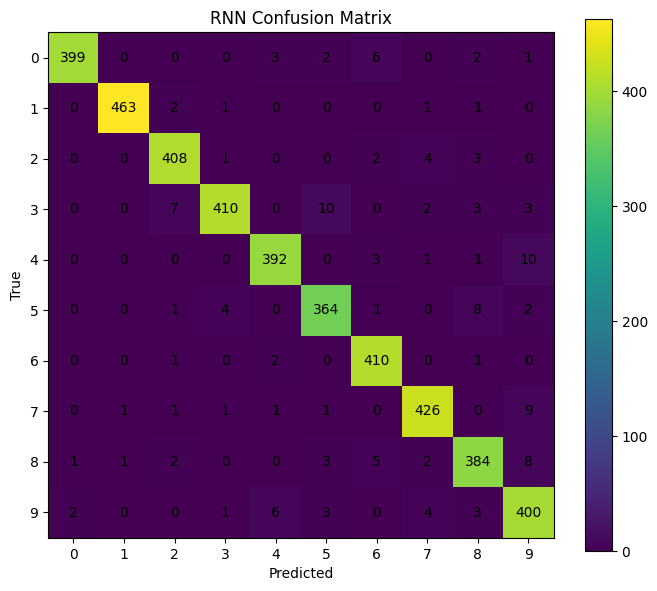

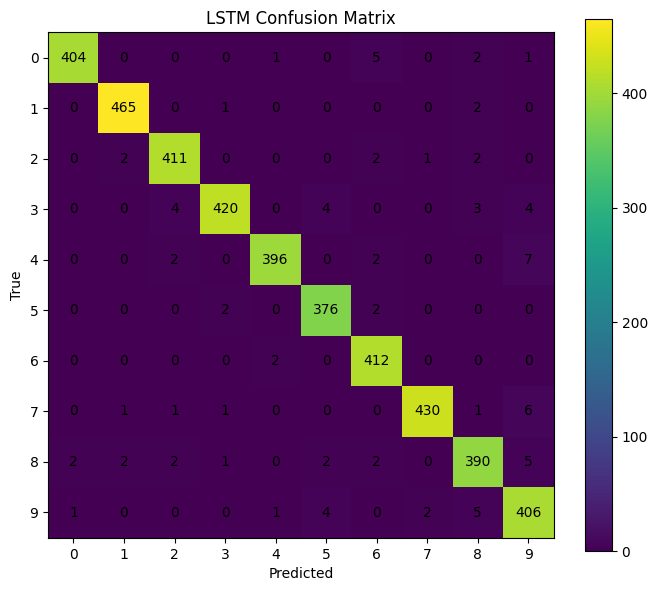

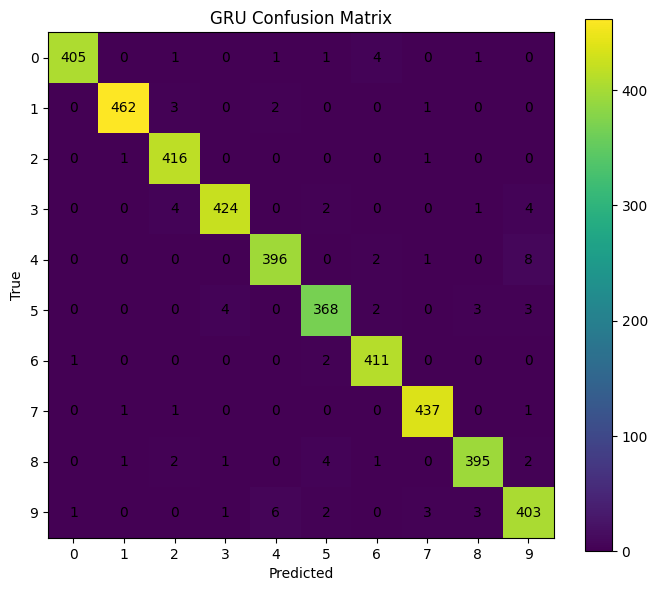

In [14]:
def show_cm(y_true, pred, title):
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(10)); plt.yticks(range(10))
    plt.xlabel("Predicted"); plt.ylabel("True")
    for i in range(10):
        for j in range(10):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

show_cm(y_val, rnn_val_pred, "RNN Confusion Matrix")
show_cm(y_val, lstm_val_pred, "LSTM Confusion Matrix")
show_cm(y_val, gru_val_pred, "GRU Confusion Matrix")

## 10. Error Analysis

The following helper displays validation images that were classified incorrectly, together with predicted confidence.

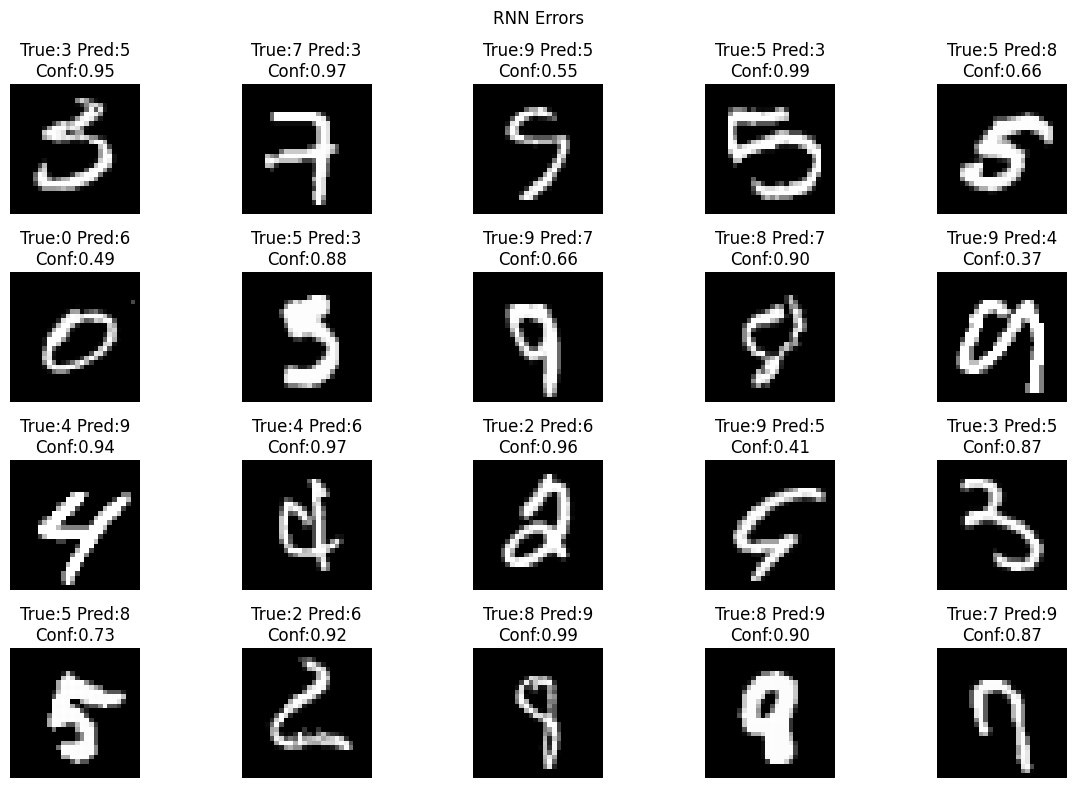

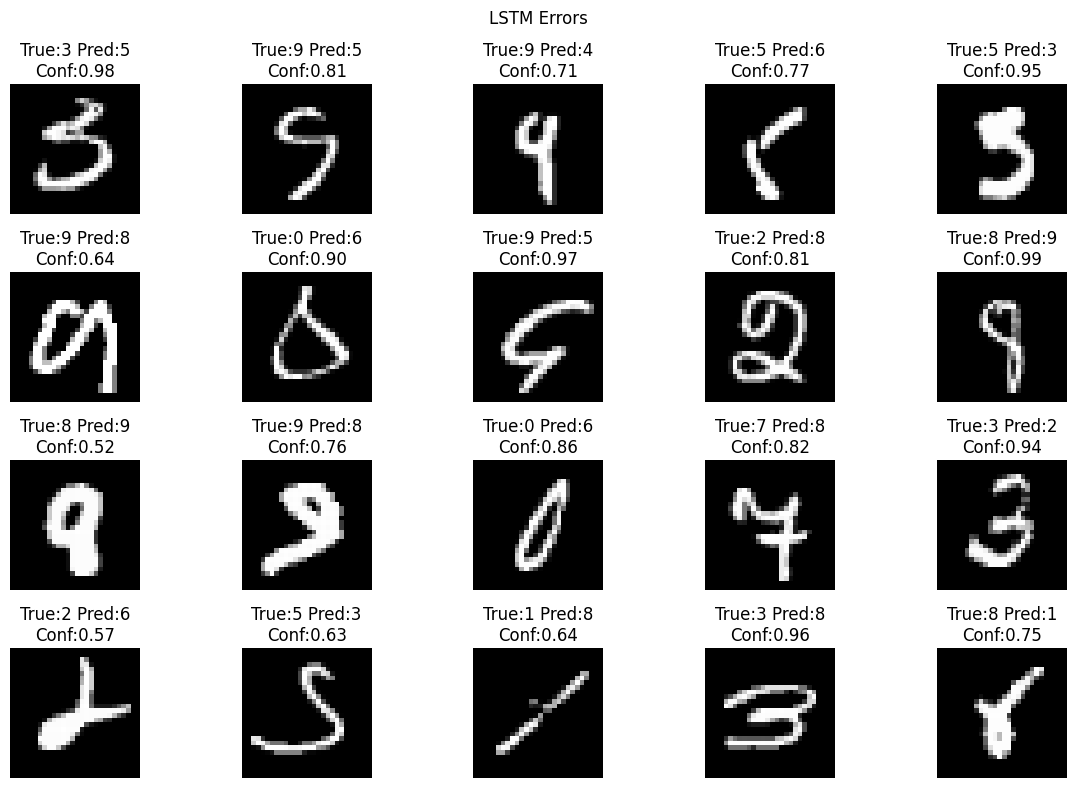

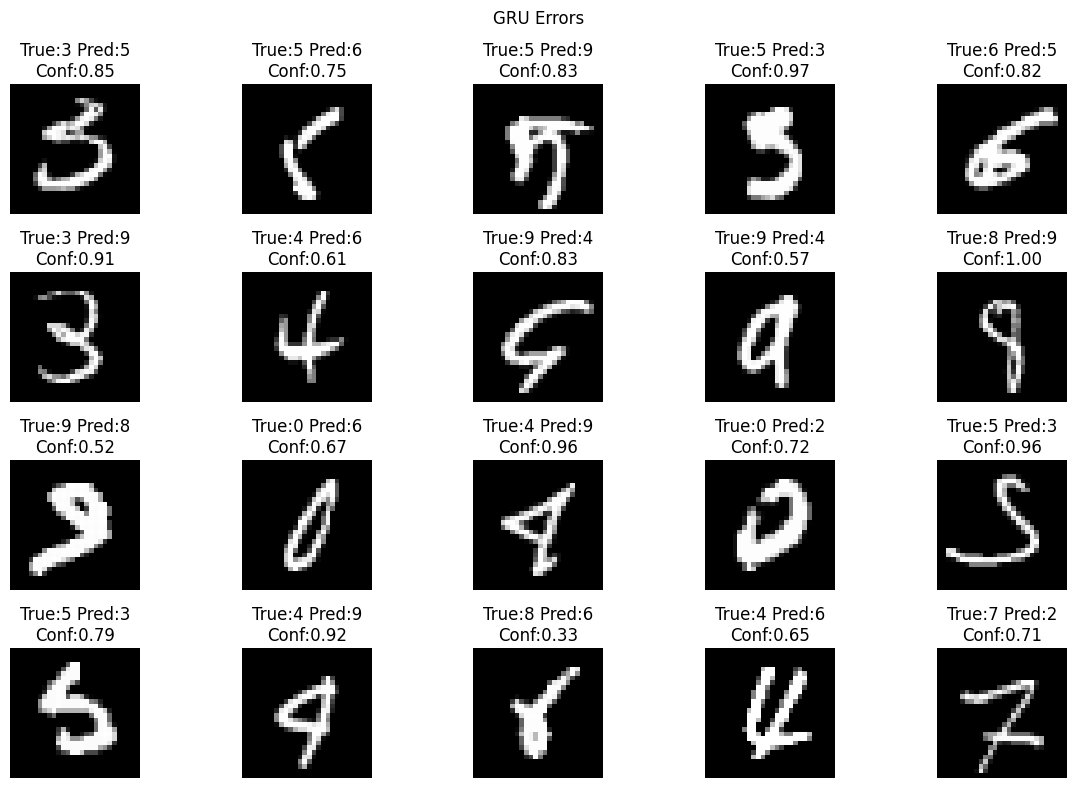

In [15]:
def show_errors(X_data, y_true, y_pred, prob, title, n=20):
    wrong = np.where(y_true != y_pred)[0][:n]
    plt.figure(figsize=(12, 8))
    for k, idx in enumerate(wrong):
        plt.subplot(4, 5, k+1)
        plt.imshow(X_data[idx], cmap="gray")
        conf = np.max(prob[idx])
        plt.title(f"True:{y_true[idx]} Pred:{y_pred[idx]}\nConf:{conf:.2f}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_errors(X_val, y_val, rnn_val_pred, rnn_val_prob, "RNN Errors")
show_errors(X_val, y_val, lstm_val_pred, lstm_val_prob, "LSTM Errors")
show_errors(X_val, y_val, gru_val_pred, gru_val_prob, "GRU Errors")

## 11. Predict the Unlabeled Kaggle Test Set

The test CSV has no true labels. Therefore, we generate predictions but do not calculate local test accuracy.

In [16]:
rnn_test_prob = rnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
lstm_test_prob = lstm_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
gru_test_prob = gru_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

rnn_test_pred = np.argmax(rnn_test_prob, axis=1)
lstm_test_pred = np.argmax(lstm_test_prob, axis=1)
gru_test_pred = np.argmax(gru_test_prob, axis=1)

comparison = pd.DataFrame({
    "ImageId": sample_submission["ImageId"].iloc[:20].values,
    "RNN": rnn_test_pred[:20],
    "LSTM": lstm_test_pred[:20],
    "GRU": gru_test_pred[:20]
})
display(comparison)

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


,ImageId,RNN,LSTM,GRU
0,1,2,2,2
1,2,0,0,0
2,3,9,9,9
3,4,9,9,9
4,5,3,3,3
5,6,9,9,7
6,7,0,0,0
7,8,3,3,3
8,9,0,0,0
9,10,3,3,3


## 12. Save Models and Submission Files

In [17]:
# Save models
rnn_model.save(BASE_PATH / "rnn_mnist.keras")
lstm_model.save(BASE_PATH / "lstm_mnist.keras")
gru_model.save(BASE_PATH / "gru_mnist.keras")

def make_submission(pred, filename):
    sub = sample_submission.copy()
    sub["Label"] = pred
    assert len(sub) == len(pred)
    assert sub["Label"].between(0, 9).all()
    path = BASE_PATH / filename
    sub.to_csv(path, index=False)
    print("Saved:", path, "Shape:", sub.shape)
    return sub

rnn_submission = make_submission(rnn_test_pred, "mnist_rnn_submission.csv")
lstm_submission = make_submission(lstm_test_pred, "mnist_lstm_submission.csv")
gru_submission = make_submission(gru_test_pred, "mnist_gru_submission.csv")

Saved: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\mnist_rnn_submission.csv Shape: (28000, 2)
Saved: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\mnist_lstm_submission.csv Shape: (28000, 2)
Saved: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\mnist_gru_submission.csv Shape: (28000, 2)


## 13. Model Confidence

Confidence is the probability assigned to the predicted class. High confidence does not guarantee correctness, so use it together with validation metrics and error analysis.

In [18]:
confidence_df = pd.DataFrame({
    "RNN": np.max(rnn_test_prob, axis=1),
    "LSTM": np.max(lstm_test_prob, axis=1),
    "GRU": np.max(gru_test_prob, axis=1)
})
display(confidence_df.describe())

,RNN,LSTM,GRU
count,28000.000000,28000.000000,28000.000000
mean,0.972571,0.986211,0.986450
std,0.086449,0.062872,0.063093
min,0.230518,0.293645,0.276008
25%,0.992998,0.998839,0.999011
50%,0.998307,0.999731,0.999774
75%,0.999347,0.999890,0.999917
max,0.999927,0.999995,0.999998
